<a href="https://colab.research.google.com/github/pantera-rosa/vuln-management-capstone/blob/eric_branch/MVP_vuln_pipeline_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP Vulnerability Pipeline — Starter Notebook

**Stages:** Input → Detection → Prioritization → (stub) Remediation → Output

This notebook wires up our three core data sources:

- **NVD CVE API (v2.0):** discovery & enrichment of CVEs for a product/CPE or keyword  
- **NVD CPE API (v2.0):** product lookup & CPE helpers  
- **EPSS API:** exploitation likelihood (probability & percentile)  


## Setup

In [ ]:

# If needed, uncomment to install deps when running locally
# %pip install requests pandas python-dateutil

import os
import math
import time
import json
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone
from urllib.parse import urlencode


## Configuration

In [ ]:

NVD_API_BASE = "https://services.nvd.nist.gov/rest/json"
NVD_CVE_ENDPOINT = f"{NVD_API_BASE}/cves/2.0"
NVD_CPE_ENDPOINT = f"{NVD_API_BASE}/cpes/2.0"

EPSS_API_BASE = "https://api.first.org/data/v1/epss"  # ?cve=CVE-2021-44228,CVE-...

NVD_API_KEY = os.getenv("NVD_API_KEY")  # set this in your environment for better rate limits

HEADERS = {
    "User-Agent": "mvp-vuln-pipeline/0.1 (contact: you@example.com)"
}


## Helper utilities

In [ ]:

def _maybe_sleep(rate_limit_ok=True):
    # Basic backoff helper — NVD allows ~50 req/30s without key; be kind.
    if not rate_limit_ok:
        time.sleep(1.2)

def _nvd_params(extra: dict) -> dict:
    params = dict(**extra)
    if NVD_API_KEY:
        params["apiKey"] = NVD_API_KEY
    return params

def chunked(iterable, size):
    buf = []
    for x in iterable:
        buf.append(x)
        if len(buf) >= size:
            yield buf
            buf = []
    if buf:
        yield buf


### NVD: CPE search

In [ ]:

import requests

def nvd_cpe_search(keyword: str = None, cpe_name: str = None, max_pages: int = 3, results_per_page: int = 200):
    """Search CPEs by keyword or exact cpeName. Returns list of CPE dicts."""
    start = 0
    out = []
    for page in range(max_pages):
        params = {"startIndex": start, "resultsPerPage": results_per_page}
        if keyword:
            params["keywordSearch"] = keyword
        if cpe_name:
            params["cpeName"] = cpe_name
        res = requests.get(NVD_CPE_ENDPOINT, headers=HEADERS, params=_nvd_params(params), timeout=60)
        if res.status_code != 200:
            raise RuntimeError(f"CPE API error: {res.status_code} {res.text[:200]}")
        data = res.json()
        items = data.get("products") or data.get("result", {}).get("cpes") or []
        out.extend(items)
        total = data.get("totalResults", 0)
        start += results_per_page
        if start >= total:
            break
        _maybe_sleep(rate_limit_ok=bool(NVD_API_KEY))
    return out


### NVD: CVE search

In [ ]:

def nvd_cve_search(
    cpe_name: str = None,
    keyword: str = None,
    pub_start: str = None,   # ISO8601: YYYY-MM-DDTHH:MM:SS:000 UTC e.g. 2024-01-01T00:00:00.000
    pub_end: str = None,
    max_pages: int = 5,
    results_per_page: int = 200,
):
    """Search CVEs in NVD v2.0, returning a flat list of CVE items."""
    start = 0
    out = []
    for page in range(max_pages):
        params = {
            "startIndex": start,
            "resultsPerPage": results_per_page,
        }
        if cpe_name:
            params["cpeName"] = cpe_name
        if keyword:
            params["keywordSearch"] = keyword
        if pub_start:
            params["pubStartDate"] = pub_start
        if pub_end:
            params["pubEndDate"] = pub_end

        res = requests.get(NVD_CVE_ENDPOINT, headers=HEADERS, params=_nvd_params(params), timeout=60)
        if res.status_code != 200:
            raise RuntimeError(f"CVE API error: {res.status_code} {res.text[:200]}")
        data = res.json()
        items = data.get("vulnerabilities") or []
        out.extend(items)
        total = data.get("totalResults", 0)
        start += results_per_page
        if start >= total:
            break
        _maybe_sleep(rate_limit_ok=bool(NVD_API_KEY))
    return out


### EPSS: fetch scores

In [ ]:

def epss_fetch(cve_ids):
    """Fetch EPSS scores for a list of CVE IDs. Returns DataFrame with columns [cve, epss, percentile]."""
    all_rows = []
    for group in chunked(cve_ids, 200):  # API is fine with large lists; chunk to be safe
        q = ",".join(group)
        url = f"{EPSS_API_BASE}?cve={q}"
        res = requests.get(url, headers=HEADERS, timeout=60)
        if res.status_code != 200:
            raise RuntimeError(f"EPSS API error: {res.status_code} {res.text[:200]}")
        payload = res.json()
        rows = payload.get("data") or []
        all_rows.extend(rows)
        _maybe_sleep(rate_limit_ok=True)
    if not all_rows:
        return pd.DataFrame(columns=["cve", "epss", "percentile"])
    df = pd.DataFrame(all_rows)
    # Ensure numeric
    for col in ("epss", "percentile"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


### NVD parsing helpers

In [ ]:

def best_cvss(vuln: dict):
    """Return (score, severity, version) from the richest metrics available (preferring v3.1 → v3.0 → v2)."""
    metrics = (vuln.get("cve") or {}).get("metrics") or {}
    # Try 3.1 then 3.0 then 2.0
    for key, ver in (("cvssMetricV31", "3.1"), ("cvssMetricV30", "3.0"), ("cvssMetricV2", "2.0")):
        arr = metrics.get(key)
        if isinstance(arr, list) and arr:
            d = arr[0].get("cvssData") or arr[0].get("cvssData", {})
            score = d.get("baseScore")
            severity = d.get("baseSeverity") or arr[0].get("baseSeverity")
            return score, severity, ver
    return None, None, None

def extract_refs(vuln: dict):
    refs = ((vuln.get("cve") or {}).get("references") or {}).get("referenceData") or []
    urls = [r.get("url") for r in refs if r.get("url")]
    return urls

def extract_cve_core(v: dict):
    c = v.get("cve") or {}
    meta = c.get("id") or c.get("CVE_data_meta", {}).get("ID")
    descs = (c.get("descriptions") or [])
    description = None
    if isinstance(descs, list) and descs:
        # choose English if present
        en = [d.get("value") for d in descs if d.get("lang") == "en" and d.get("value")]
        description = (en[0] if en else descs[0].get("value"))
    published = v.get("published") or v.get("publishedDate")
    last_mod = v.get("lastModified") or v.get("lastModifiedDate")
    score, severity, cvss_ver = best_cvss(v)
    return {
        "cve": meta,
        "description": description,
        "published": published,
        "lastModified": last_mod,
        "cvss_score": score,
        "cvss_severity": severity,
        "cvss_version": cvss_ver,
        "references": extract_refs(v),
    }


### Prioritization: simple scoring

In [ ]:

def normalize_series(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0:
        return s
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return s.fillna(0)
    return (s - mn) / (mx - mn)

def compute_priority(df: pd.DataFrame, now_utc=None):
    """Combine EPSS, CVSS, and recency (days since publish) into a 0–1 priority score.
    Weights: EPSS 0.5, CVSS 0.3, Recency 0.2 (newer = higher).
    """
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)
    # parse publish date
    def days_since(d):
        try:
            return (now_utc - datetime.fromisoformat(d.replace("Z", "+00:00"))).days
        except Exception:
            return None
    df = df.copy()
    df["days_since_publish"] = df["published"].apply(days_since)
    # recency: newer CVEs get higher score
    recency = df["days_since_publish"].apply(lambda x: None if x is None else max(0, x))
    recency_norm = 1 - normalize_series(recency)  # smaller days → closer to 1
    cvss_norm = df["cvss_score"] / 10.0
    epss = df["epss"].fillna(0)

    df["priority_score"] = (0.5 * epss.fillna(0)) + (0.3 * cvss_norm.fillna(0)) + (0.2 * recency_norm.fillna(0))
    return df.sort_values("priority_score", ascending=False)


### (Optional) CVEList v5 enrichment

In [ ]:

from pathlib import Path
import json

def cvelist_enrich(df: pd.DataFrame, cvelist_root: str = None) -> pd.DataFrame:
    """If you have the CVEList v5 repo locally, you can enrich descriptions.
    Set `cvelist_root` to the cloned repo path (e.g., '/path/to/cvelistV5').
    This is a lightweight stub; directory layout may change — adjust as needed.
    """
    if not cvelist_root:
        return df
    root = Path(cvelist_root)
    if not root.exists():
        print(f"CVEList root not found: {root}")
        return df

    # naive attempt: {root}/**/YYYY/**/CVE-YYYY-XXXX.json
    extra_desc = {}
    for cve in df["cve"].dropna().unique():
        try:
            year = cve.split("-")[1]
            candidates = list(root.glob(f"**/{year}/**/{cve}.json"))
            if not candidates:
                continue
            p = candidates[0]
            data = json.loads(p.read_text(encoding="utf-8", errors="ignore"))
            containers = (data.get("containers") or {})
            cna = containers.get("cna") or {}
            descs = cna.get("descriptions") or []
            en = [d.get("value") for d in descs if d.get("lang") == "en" and d.get("value")]
            if en:
                extra_desc[cve] = en[0]
        except Exception:
            pass

    if extra_desc:
        df = df.copy()
        df["description"] = df.apply(lambda r: extra_desc.get(r["cve"], r["description"]), axis=1)
    return df


### (Stub) Remediation suggestions

In [ ]:

def remediation_stub(row):
    """Very basic heuristic guidance — replace with package-manager aware logic later."""
    hints = []
    refs = row.get("references") or []
    if any(("advisories" in (u or "").lower()) or ("security" in (u or "").lower()) for u in refs):
        hints.append("Review vendor advisory and apply the recommended patch or upgrade.")
    if any(("commit" in (u or "").lower()) or ("patch" in (u or "").lower()) for u in refs):
        hints.append("A code-level patch or commit is referenced — consider updating to a version including that fix.")
    if not hints:
        hints.append("If this affects a dependency you control, upgrade to a non-vulnerable version as soon as feasible.")
    return " ".join(hints)


In [ ]:
# --- PATCH: handle NVD v2.0 references + publish/lastModified fields ---

def extract_refs(vuln: dict):
    c = (vuln.get("cve") or {})
    refs = c.get("references") or []
    # NVD v2.0: list of {url, ...}
    if isinstance(refs, list):
        return [r.get("url") for r in refs if isinstance(r, dict) and r.get("url")]
    # Legacy shape: {"referenceData": [...]}
    if isinstance(refs, dict):
        data = refs.get("referenceData") or []
        return [r.get("url") for r in data if isinstance(r, dict) and r.get("url")]
    return []

def extract_cve_core(v: dict):
    c = v.get("cve") or {}
    meta = c.get("id") or (c.get("CVE_data_meta", {}) or {}).get("ID")

    # description (prefer English)
    descs = c.get("descriptions") or []
    description = None
    if isinstance(descs, list) and descs:
        en = [d.get("value") for d in descs if isinstance(d, dict) and d.get("lang") == "en" and d.get("value")]
        description = en[0] if en else (descs[0].get("value") if isinstance(descs[0], dict) else str(descs[0]))

    # timestamps (v2.0 puts these under cve)
    published   = c.get("published")    or v.get("published")    or v.get("publishedDate")
    last_mod    = c.get("lastModified") or v.get("lastModified") or v.get("lastModifiedDate")

    # CVSS
    score, severity, cvss_ver = best_cvss(v)

    return {
        "cve": meta,
        "description": description,
        "published": published,
        "lastModified": last_mod,
        "cvss_score": score,
        "cvss_severity": severity,
        "cvss_version": cvss_ver,
        "references": extract_refs(v),
    }


## End-to-end demo

In [ ]:

# --- Configure your targets here ---
# Option A: keyword search (broad). Example: 'log4j'
KEYWORDS = ["log4j"]

# Option B: exact CPE name. Example for Apache Log4j core:
#   'cpe:2.3:a:apache:log4j:*:*:*:*:*:*:*:*'
CPES = []  # e.g., ["cpe:2.3:a:apache:log4j:*:*:*:*:*:*:*:*"]

# Optional date window (ISO8601). Example:
# PUB_START = "2021-01-01T00:00:00.000"
# PUB_END   = "2025-12-31T23:59:59.999"
PUB_START = None
PUB_END = None

# Optional: CVEList path for local enrichment
CVELIST_ROOT = None  # e.g., r"/path/to/cvelistV5"

# --- Detection: pull from NVD ---
cve_items = []

for kw in KEYWORDS:
    cve_items.extend(nvd_cve_search(keyword=kw, pub_start=PUB_START, pub_end=PUB_END, max_pages=2))

for cpe in CPES:
    cve_items.extend(nvd_cve_search(cpe_name=cpe, pub_start=PUB_START, pub_end=PUB_END, max_pages=4))

# Deduplicate by CVE ID
flat = [extract_cve_core(v) for v in cve_items]
df = pd.DataFrame(flat).drop_duplicates(subset=["cve"]).reset_index(drop=True)
print(f"Fetched {len(df)} unique CVEs from NVD.")

# --- Prioritization: EPSS + CVSS + recency ---
if not df.empty:
    epss_df = epss_fetch(df["cve"].tolist())
    df = df.merge(epss_df, how="left", left_on="cve", right_on="cve")

    # Optional: CVEList enrichment
    df = cvelist_enrich(df, CVELIST_ROOT)

    df = compute_priority(df)

# --- (Stub) Remediation ---
if not df.empty:
    df["remediation_hint"] = df.apply(remediation_stub, axis=1)

# --- Output ---
cols = ["priority_score","cve","epss","percentile","cvss_score","cvss_severity","published","description","remediation_hint"]
out = df[cols].sort_values("priority_score", ascending=False).reset_index(drop=True)
out.head(20)


Fetched 25 unique CVEs from NVD.


,priority_score,cve,epss,percentile,cvss_score,cvss_severity,published,description,remediation_hint
0,0.771790,CVE-2021-44228,0.94358,0.99956,10.0,CRITICAL,2021-12-10T10:15:09.143,Apache Log4j2 2.0-beta9 through 2.15.0 (exclud...,Review vendor advisory and apply the recommend...
1,0.764065,CVE-2017-5645,0.94013,0.99890,9.8,CRITICAL,2017-04-17T21:59:00.373,"In Apache Log4j 2.x before 2.8.2, when using t...",Review vendor advisory and apply the recommend...
2,0.741700,CVE-2021-45046,0.94340,0.99950,9.0,CRITICAL,2021-12-14T19:15:07.733,It was found that the fix to address CVE-2021-...,Review vendor advisory and apply the recommend...
3,0.586010,CVE-2021-4104,0.72202,0.98715,7.5,HIGH,2021-12-14T12:15:12.200,JMSAppender in Log4j 1.2 is vulnerable to dese...,Review vendor advisory and apply the recommend...
4,0.564150,CVE-2019-17571,0.54030,0.97937,9.8,CRITICAL,2019-12-20T17:15:11.893,Included in Log4j 1.2 is a SocketServer class ...,Review vendor advisory and apply the recommend...
5,0.529155,CVE-2021-45105,0.70431,0.98652,5.9,MEDIUM,2021-12-18T12:15:07.433,Apache Log4j2 versions 2.0-alpha1 through 2.16...,Review vendor advisory and apply the recommend...
6,0.465955,CVE-2021-44832,0.53591,0.97918,6.6,MEDIUM,2021-12-28T20:15:08.400,Apache Log4j2 versions 2.0-beta7 through 2.17....,Review vendor advisory and apply the recommend...
7,0.364680,CVE-2022-23305,0.14136,0.94162,9.8,CRITICAL,2022-01-18T16:15:08.350,"By design, the JDBCAppender in Log4j 1.2.x acc...",Review vendor advisory and apply the recommend...
8,0.312760,CVE-2024-23049,0.03752,0.87573,9.8,CRITICAL,2024-02-05T23:15:08.463,An issue in symphony v.3.6.3 and before allows...,"If this affects a dependency you control, upgr..."
9,0.296520,CVE-2022-23848,0.00504,0.65230,9.8,CRITICAL,2022-02-20T19:15:09.410,"In Alluxio before 2.7.3, the logserver does no...","If this affects a dependency you control, upgr..."


### Quick chart: top 15 by priority

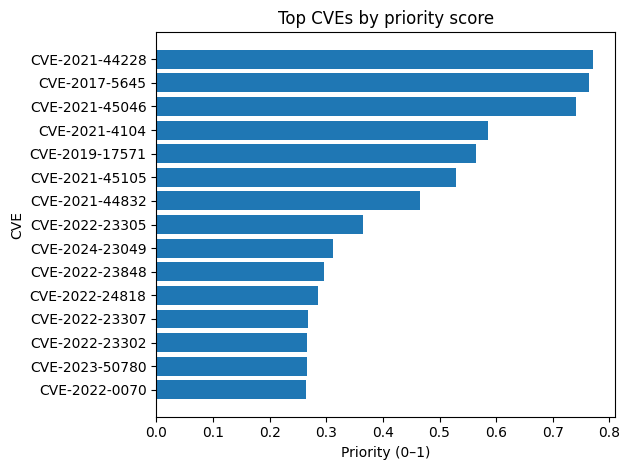

In [ ]:

import matplotlib.pyplot as plt

if 'out' in globals() and not out.empty:
    top = out.head(15)
    plt.figure()
    plt.barh(top["cve"][::-1], top["priority_score"][::-1])
    plt.title("Top CVEs by priority score")
    plt.xlabel("Priority (0–1)")
    plt.ylabel("CVE")
    plt.tight_layout()
else:
    print("No data to chart yet.")


### Save results

In [ ]:

SAVE_PATH = "mvp_vuln_results.csv"
if 'out' in globals() and not out.empty:
    out.to_csv(SAVE_PATH, index=False)
    print(f"Saved: {SAVE_PATH}")
else:
    print("Nothing to save.")



## Next steps

- **Input:** Parse SBOM (SPDX/CycloneDX) → map packages to CPEs (or package-to-CVE via OSV).
- **Detection:** Query NVD using precise CPEs; consider OSV for package ecosystems.
- **Prioritization:** Add KEV (known-exploited) & asset criticality. Tune weights per service.
- **Remediation:** Integrate package managers (npm, Maven, PyPI, etc.) to suggest exact fixed versions.
  Optionally auto-open GitHub issues/PRs with explainable descriptions.
- **Output:** Persist to a DB and surface a UI/API for teams.

> This notebook is intentionally minimal to get data flowing. Expand each stage as you integrate with your repo/SBOM.
